# slim-llm-memory — verification notebook

Exercises the phase-1 `Memory` core in three parts:

| Part | What | Embedder | Network |
|---|---|---|---|
| 1 | **Correctness cases** — upsert / hash-skip / search / filters / delete / persistence / crash-safety / lock / compaction / duplicates / validation | `Embedder.noop()` + small controlled embedders | none |
| 2 | **Speed** — upsert, search, flush+reload, duplicate scan vs. index size | fast synthetic numpy embedder (isolates index cost from embedding cost) | none |
| 3 | **Use cases** — personal notes brain, RAG over this repo's docs, incremental re-index, near-duplicate detection, chat memory, real-embedder latency | `Embedder.ollama("nomic-embed-text")` | local Ollama (skipped if unreachable) |

Every case records a result via `check(...)`: ✅ pass, ❌ unexpected failure, ⚠️ a **known library issue** this
notebook documents on purpose (it flips to ✅ once fixed). A summary table is printed at the end.

Run top-to-bottom: `jupyter nbconvert --to notebook --execute --inplace notebooks/verify_memory.ipynb`
(or just *Run All* in JupyterLab). Part 3 needs `ollama pull nomic-embed-text`.

In [1]:
import sys, os, time, json, shutil, tempfile, statistics, textwrap, hashlib
from pathlib import Path
import numpy as np

# Make the repo importable without installing it.
REPO = Path.cwd().resolve()
while not (REPO / "slim_llm_memory").exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from slim_llm_memory import Memory, Embedder, EmbedderError, Hit
from slim_llm_memory.store import StoreError

print("repo:", REPO)
print("numpy:", np.__version__, "| python:", sys.version.split()[0])

# ── tiny test harness ────────────────────────────────────────────────────
RESULTS: list[tuple[str, str, bool, str]] = []   # (part, name, ok, detail)
_PART = "setup"

def part(name):
    global _PART
    _PART = name

KNOWN: set[str] = set()   # names of checks that document a known library issue

def check(name, cond, detail="", known=False):
    # known=True marks a check that documents a known library sharp corner:
    # it still runs and reports, but is shown as ⚠️ and counted separately.
    ok = bool(cond)
    if known: KNOWN.add(name)
    RESULTS.append((_PART, name, ok, str(detail)))
    icon = "✅" if ok else ("⚠️ " if known else "❌")
    print(icon, name, ("— " + str(detail)) if detail else "")
    return ok

def expect_raises(exc_type, fn, *a, **kw):
    try:
        fn(*a, **kw)
    except exc_type as e:
        return e
    except Exception as e:
        return f"WRONG EXCEPTION {type(e).__name__}: {e}"
    return None

class Timer:
    def __enter__(self):
        self.t0 = time.perf_counter(); return self
    def __exit__(self, *a):
        self.s = time.perf_counter() - self.t0
        self.ms = self.s * 1000

def fresh_dir(tag="mem"):
    return Path(tempfile.mkdtemp(prefix=f"slim_{tag}_"))

# ── embedders used in Parts 1–2 ──────────────────────────────────────────
class CountingEmbedder(Embedder):
    '''Wraps another embedder and counts how many texts actually got embedded.'''
    def __init__(self, inner):
        self.inner = inner; self.name = inner.name; self.dim = inner.dim
        self.calls = 0; self.texts = 0
    def embed(self, texts):
        self.calls += 1; self.texts += len(texts)
        return self.inner.embed(texts)

class ControlledEmbedder(Embedder):
    '''Maps text → a hand-picked direction so similarity is predictable.
    Unknown texts fall back to a deterministic pseudo-random vector.'''
    def __init__(self, table: dict[str, np.ndarray], dim=8):
        self.table = {k: np.asarray(v, dtype=np.float32) for k, v in table.items()}
        self.dim = dim; self.name = f"controlled:{dim}"
    def embed(self, texts):
        out = []
        for t in texts:
            if t in self.table:
                out.append(self.table[t].tolist())
            else:
                seed = int(hashlib.sha256(t.encode()).hexdigest()[:8], 16)
                out.append(np.random.default_rng(seed).standard_normal(self.dim).tolist())
        return out

class FastRandomEmbedder(Embedder):
    '''numpy-vectorised deterministic embedder for benchmarks (µs per text).'''
    def __init__(self, dim=384):
        self.dim = dim; self.name = f"fastrand:{dim}"
    def embed(self, texts):
        seeds = [int(hashlib.blake2b(t.encode(), digest_size=4).hexdigest(), 16) for t in texts]
        rng = np.random.default_rng(seeds)
        return rng.standard_normal((len(texts), self.dim), dtype=np.float32).tolist()

print("harness ready")

repo: /home/trbck/workspace/slim-llm-memory
numpy: 2.4.6 | python: 3.11.15
harness ready


## Part 1 — Correctness cases (offline)

`Embedder.noop()` derives a unit vector from SHA-256 of the text, so identical text ⇒ identical vector
(cosine 1.0) and different text ⇒ essentially random direction (cosine ≈ 0). That makes exact-match,
skip and delete behaviour fully deterministic without any model.

In [2]:
part("1. upsert semantics")
d = fresh_dir("upsert")
emb = CountingEmbedder(Embedder.noop(dim=64))
mem = Memory(d, emb)

DOCS = [
    {"id": "a", "text": "alpha document", "meta": {"kind": "note"}},
    {"id": "b", "text": "beta document",  "meta": {"kind": "note"}},
    {"id": "c", "text": "gamma document", "meta": {"kind": "idea"}},
]
r1 = mem.upsert(DOCS)
print("first upsert:", r1)
check("3 new items → added=3", r1["added"] == 3 and r1["updated"] == 0 and r1["skipped"] == 0, r1)
check("one batched embed call for 3 texts", emb.calls == 1 and emb.texts == 3, f"calls={emb.calls} texts={emb.texts}")

r2 = mem.upsert([{"id": "a", "text": "alpha document REVISED", "meta": {"kind": "note"}}])
print("update a:", r2)
check("changed text → updated=1", r2 == {"added": 0, "updated": 1, "skipped": 0, "embed_calls": 1}, r2)

r3 = mem.upsert([])
check("empty upsert is a no-op", r3 == {"added": 0, "updated": 0, "skipped": 0, "embed_calls": 0}, r3)
check("stats.items_open == 3", mem.stats()["items_open"] == 3, mem.stats()["items_open"])
mem.close()

first upsert: {'added': 3, 'updated': 0, 'skipped': 0, 'embed_calls': 1}
✅ 3 new items → added=3 — {'added': 3, 'updated': 0, 'skipped': 0, 'embed_calls': 1}
✅ one batched embed call for 3 texts — calls=1 texts=3
update a: {'added': 0, 'updated': 1, 'skipped': 0, 'embed_calls': 1}
✅ changed text → updated=1 — {'added': 0, 'updated': 1, 'skipped': 0, 'embed_calls': 1}
✅ empty upsert is a no-op — {'added': 0, 'updated': 0, 'skipped': 0, 'embed_calls': 0}
✅ stats.items_open == 3 — 3


In [3]:
part("2. hash-skip incremental re-index")
d = fresh_dir("hashskip")
emb = CountingEmbedder(Embedder.noop(dim=64))
mem = Memory(d, emb)
mem.upsert(DOCS)
before = emb.texts

# Same text, new meta → must NOT call the embedder, but meta must update.
r = mem.upsert([{**doc, "meta": {"kind": "note", "tag": "v2"}} for doc in DOCS])
print("re-upsert identical text:", r)
check("all 3 skipped, 0 embed calls", r["skipped"] == 3 and r["embed_calls"] == 0, r)
check("embedder never invoked", emb.texts == before, f"texts embedded={emb.texts}")
check("meta was still updated", mem.search("alpha document", k=1)[0].meta.get("tag") == "v2")

# Change ONE text out of three → exactly one text embedded.
# (search() above embedded its query, so re-baseline the counter here.)
before = emb.texts
changed = [dict(doc) for doc in DOCS]; changed[1]["text"] = "beta document (edited)"
r = mem.upsert(changed)
print("edit one of three:", r)
check("1 updated, 2 skipped", r["updated"] == 1 and r["skipped"] == 2, r)
check("exactly 1 text embedded", emb.texts == before + 1, f"delta={emb.texts - before}")

# update_text convenience
check("update_text on unknown id → False", mem.update_text("nope", "x") is False)
check("update_text on known id → True", mem.update_text("c", "gamma document v3") is True)
check("update_text keeps meta", mem.search("gamma document v3", k=1)[0].meta == {"kind": "idea"})
print("counters:", mem.stats()["counters"])
mem.close()

re-upsert identical text: {'added': 0, 'updated': 0, 'skipped': 3, 'embed_calls': 0}
✅ all 3 skipped, 0 embed calls — {'added': 0, 'updated': 0, 'skipped': 3, 'embed_calls': 0}
✅ embedder never invoked — texts embedded=3
✅ meta was still updated 
edit one of three: {'added': 0, 'updated': 1, 'skipped': 2, 'embed_calls': 1}
✅ 1 updated, 2 skipped — {'added': 0, 'updated': 1, 'skipped': 2, 'embed_calls': 1}
✅ exactly 1 text embedded — delta=1
✅ update_text on unknown id → False 
✅ update_text on known id → True 
✅ update_text keeps meta 
counters: {'embed.calls': 3, 'embed.items': 5, 'upsert.added': 3, 'upsert.skipped_text_unchanged': 5, 'search.calls': 2, 'upsert.updated': 2}


In [4]:
part("3. search basics, filters, edge cases")
d = fresh_dir("search")
mem = Memory(d, Embedder.noop(dim=128))
mem.upsert(DOCS)

hits = mem.search("alpha document", k=3)
print([(h.id, round(h.score, 4)) for h in hits])
check("exact text → itself at rank 1 with cosine ≈ 1.0", hits[0].id == "a" and abs(hits[0].score - 1.0) < 1e-5, hits[0].score)
check("Hit dataclass carries id/score/text/meta", isinstance(hits[0], Hit) and hits[0].text == "alpha document" and hits[0].meta == {"kind": "note"})
check("scores sorted descending", all(hits[i].score >= hits[i+1].score for i in range(len(hits)-1)))

# default min_score=0 → only non-negative cosines; noop vectors are random so some drop out.
allhits = mem.search("zzz unrelated", k=10, min_score=-1.0)
check("min_score=-1 returns everything (3)", len(allhits) == 3, len(allhits))

# kinds filter
ideas = mem.search("alpha document", k=10, kinds={"idea"}, min_score=-1.0)
check("kinds={'idea'} → only c", [h.id for h in ideas] == ["c"], [h.id for h in ideas])
none = mem.search("alpha document", k=10, kinds={"nonexistent"}, min_score=-1.0)
check("kinds with no members → []", none == [])

# min_score cut
strict = mem.search("alpha document", k=10, min_score=0.99)
check("min_score=0.99 keeps only the exact match", [h.id for h in strict] == ["a"])

# k edge cases
check("k=1 → 1 hit", len(mem.search("alpha document", k=1, min_score=-1)) == 1)
check("k=0 → []", mem.search("alpha document", k=0) == [])
check("k > N → N hits", len(mem.search("alpha document", k=100, min_score=-1)) == 3)
check("empty query → []", mem.search("", k=5) == [])
check("whitespace query → []", mem.search("   \n", k=5) == [])

empty = Memory(fresh_dir("empty"), Embedder.noop(dim=128))
check("search on empty store → []", empty.search("anything") == [])
empty.close(); mem.close()

[('a', 1.0), ('b', -0.0477), ('c', -0.0955)]
✅ exact text → itself at rank 1 with cosine ≈ 1.0 — 1.0
✅ Hit dataclass carries id/score/text/meta 
✅ scores sorted descending 
✅ min_score=-1 returns everything (3) — 3
✅ kinds={'idea'} → only c — ['c']
✅ kinds with no members → [] 
✅ min_score=0.99 keeps only the exact match 
✅ k=1 → 1 hit 
✅ k=0 → [] 
✅ k > N → N hits 
✅ empty query → [] 
✅ whitespace query → [] 
✅ search on empty store → [] 


In [5]:
part("4. remove / tombstones")
d = fresh_dir("remove")
mem = Memory(d, Embedder.noop(dim=64))
mem.upsert(DOCS)

check("remove existing → True", mem.remove("b") is True)
check("remove again → False", mem.remove("b") is False)
check("remove unknown → False", mem.remove("zzz") is False)
ids = [h.id for h in mem.search("beta document", k=10, min_score=-1)]
check("removed item never returned by search", "b" not in ids, ids)
s = mem.stats()
check("stats: 3 rows, 2 open, 1 tombstone", (s["items"], s["items_open"], s["tombstones"]) == (3, 2, 1), s)
check("kinds filter still excludes tombstone", "b" not in [h.id for h in mem.search("x", k=10, kinds={"note"}, min_score=-1)])

# Re-adding a removed id → fresh insert (new row), old tombstone stays until compaction.
r = mem.upsert([{"id": "b", "text": "beta document"}])
check("re-upsert of removed id counts as added", r["added"] == 1, r)
check("re-added id is searchable again", mem.search("beta document", k=1)[0].id == "b")
mem.close()

✅ remove existing → True 
✅ remove again → False 
✅ remove unknown → False 
✅ removed item never returned by search — ['c', 'a']
✅ stats: 3 rows, 2 open, 1 tombstone — {'items': 3, 'items_open': 2, 'tombstones': 1, 'embedder': 'noop:64', 'embed_dim': 64, 'version': 0, 'dirty': True, 'file_age_seconds': None, 'needs_compaction': True, 'counters': {'embed.calls': 1, 'embed.items': 3, 'upsert.added': 3, 'remove': 1, 'search.calls': 1}, 'embed_errors_1h': 0, 'embed_errors_24h': 0, 'llm_errors_1h': 0, 'llm_errors_24h': 0, 'slow_queries': [], 'uptime_seconds': 0, 'buffer_cap': 50, 'slow_threshold_ms': 100}
✅ kinds filter still excludes tombstone 
✅ re-upsert of removed id counts as added — {'added': 1, 'updated': 0, 'skipped': 0, 'embed_calls': 1}
✅ re-added id is searchable again 


In [6]:
part("5. persistence round-trip")
d = fresh_dir("persist")
mem = Memory(d, Embedder.noop(dim=64))
mem.upsert(DOCS)
check("flush() on dirty store → True", mem.flush() is True)
check("flush() again with nothing dirty → False", mem.flush() is False)
check("flush(force=True) → True", mem.flush(force=True) is True)
files = sorted(p.name for p in d.iterdir())
print("files:", files)
check("exactly one items/vectors version on disk + manifest + .lock",
      files == [".lock", "items.v2.jsonl", "manifest.json", "vectors.v2.npy"], files)
manifest = json.loads((d / "manifest.json").read_text())
check("manifest records embedder + n", manifest["embedder"] == {"name": "noop:64", "dim": 64} and manifest["n"] == 3, manifest)
before = [(h.id, round(h.score, 6)) for h in mem.search("alpha document", k=3, min_score=-1)]
mem.close()

mem2 = Memory(d, Embedder.noop(dim=64))
after = [(h.id, round(h.score, 6)) for h in mem2.search("alpha document", k=3, min_score=-1)]
check("reopen: same items", mem2.stats()["items_open"] == 3)
check("reopen: identical search results", before == after, f"{before} vs {after}")
r = mem2.upsert(DOCS)
check("reopen: hashes survived → all skipped, 0 embeds", r["skipped"] == 3 and r["embed_calls"] == 0, r)
mem2.close()          # close() auto-flushes by default

# Unflushed changes are lost by design (explicit flush model)
mem3 = Memory(d, Embedder.noop(dim=64)); mem3.upsert([{"id": "ghost", "text": "never flushed"}]); mem3.close(flush=False)
mem4 = Memory(d, Embedder.noop(dim=64))
check("close(flush=False) discards unflushed writes", mem4.stats()["items_open"] == 3)
mem4.close()

✅ flush() on dirty store → True 
✅ flush() again with nothing dirty → False 
✅ flush(force=True) → True 
files: ['.lock', 'items.v2.jsonl', 'manifest.json', 'vectors.v2.npy']
✅ exactly one items/vectors version on disk + manifest + .lock — ['.lock', 'items.v2.jsonl', 'manifest.json', 'vectors.v2.npy']
✅ manifest records embedder + n — {'version': 2, 'embedder': {'name': 'noop:64', 'dim': 64}, 'n': 3, 'n_open': 3, 'ts': 1788460292.1988025}
✅ reopen: same items 
✅ reopen: identical search results — [('a', 1.0), ('b', -0.024041), ('c', -0.204818)] vs [('a', 1.0), ('b', -0.024041), ('c', -0.204818)]
✅ reopen: hashes survived → all skipped, 0 embeds — {'added': 0, 'updated': 0, 'skipped': 3, 'embed_calls': 0}
✅ close(flush=False) discards unflushed writes 


In [7]:
part("6. crash safety (manifest is the commit point)")
d = fresh_dir("crash")
mem = Memory(d, Embedder.noop(dim=64)); mem.upsert(DOCS); mem.flush(); mem.close()
v = json.loads((d / "manifest.json").read_text())["version"]

# Simulate a crash mid-flush: a partially written NEXT version exists, manifest still points at v.
(d / f"items.v{v+1}.jsonl").write_text('{"id": "half", "text": "wri')     # truncated line
(d / f"vectors.v{v+1}.npy").write_bytes(b"\x93NUMPY garbage")
mem = Memory(d, Embedder.noop(dim=64))
check("loads the committed version, ignores half-written next version",
      mem.stats()["version"] == v and mem.stats()["items_open"] == 3)
mem.close()

def snapshot(src, tag):
    # Copy an index dir (minus the lock file) so each failure case gets its own directory.
    dst = fresh_dir(tag); shutil.rmtree(dst)
    shutil.copytree(src, dst, ignore=shutil.ignore_patterns(".lock")); return dst

# Corrupt the manifest itself → clear StoreError, not a silent empty index.
d1 = snapshot(d, "crash_manifest"); (d1 / "manifest.json").write_text("{not json")
e = expect_raises(StoreError, Memory, d1, Embedder.noop(dim=64))
check("corrupt manifest → StoreError", isinstance(e, StoreError) and "corrupt manifest" in str(e), e)

# Manifest points at files that don't exist
d2 = snapshot(d, "crash_missing")
(d2 / "manifest.json").write_text(json.dumps({"version": 99, "embedder": {"name": "noop:64", "dim": 64}}))
e = expect_raises(StoreError, Memory, d2, Embedder.noop(dim=64))
check("manifest → missing files → StoreError", isinstance(e, StoreError) and "files missing" in str(e), e)

# Corrupt jsonl line at the committed version
d3 = snapshot(d, "crash_jsonl")
p = d3 / f"items.v{v}.jsonl"; p.write_text(p.read_text() + "{broken\n")
e = expect_raises(StoreError, Memory, d3, Embedder.noop(dim=64))
check("corrupt jsonl → StoreError naming the line", isinstance(e, StoreError) and "line" in str(e), e)

✅ loads the committed version, ignores half-written next version 
✅ corrupt manifest → StoreError — corrupt manifest at /tmp/slim_crash_manifest_g9ha47bv/manifest.json: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
✅ manifest → missing files → StoreError — manifest points at version 99 but files missing: items_exists=False vectors_exists=False
✅ corrupt jsonl → StoreError naming the line — corrupt items.jsonl at line 4: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)


True

In [8]:
part("7. single-writer lock & embedder fingerprint")
d = fresh_dir("lock")
m1 = Memory(d, Embedder.noop(dim=64))
e = expect_raises(StoreError, Memory, d, Embedder.noop(dim=64))
check("second writer on same dir → StoreError", isinstance(e, StoreError), e)
m1.upsert(DOCS); m1.close()
m2 = Memory(d, Embedder.noop(dim=64))
check("lock released after close → reopen works", m2.stats()["items_open"] == 3)
m2.close()

e = expect_raises(StoreError, Memory, snapshot(d, "fp_dim"), Embedder.noop(dim=128))
check("different dim → StoreError", isinstance(e, StoreError) and "mismatch" in str(e), e)
e = expect_raises(StoreError, Memory, snapshot(d, "fp_name"), FastRandomEmbedder(dim=64))
check("different embedder name → StoreError", isinstance(e, StoreError) and "mismatch" in str(e), e)

# Known issue: Store.__init__ acquires the lock BEFORE _load_or_init(); if loading raises,
# the lock fd is never released, so the directory stays locked for the rest of the process.
dl = snapshot(d, "lockleak")
expect_raises(StoreError, Memory, dl, Embedder.noop(dim=128))       # fails on fingerprint mismatch …
e = expect_raises(StoreError, Memory, dl, Embedder.noop(dim=64))    # … correct embedder should now work
check("lock released when Memory() fails during load  [store.py Store.__init__]", e is None,
      "still locked: " + str(e) if e else "", known=True)

# context manager
with Memory(fresh_dir("ctx"), Embedder.noop(dim=32)) as m:
    m.upsert(DOCS)
    check("context manager works", m.stats()["items_open"] == 3)
e = expect_raises(TypeError, Memory, fresh_dir("badtype"), "not-an-embedder")
check("non-Embedder → TypeError", isinstance(e, TypeError), e)

✅ second writer on same dir → StoreError — another writer holds the lock: /tmp/slim_lock_ig81onjv/.lock
✅ lock released after close → reopen works 
✅ different dim → StoreError — embedder mismatch: index built with 'noop:64' (dim=64) but configured embedder is 'noop:128' (dim=128). Delete the index directory or use the matching embedder.
✅ different embedder name → StoreError — embedder mismatch: index built with 'noop:64' (dim=64) but configured embedder is 'fastrand:64' (dim=64). Delete the index directory or use the matching embedder.
✅ lock released when Memory() fails during load  [store.py Store.__init__] 
✅ context manager works 
✅ non-Embedder → TypeError — embedder must be an Embedder instance


True

In [9]:
part("8. compaction (>20% tombstones)")
def make(n, tag):
    m = Memory(fresh_dir(tag), Embedder.noop(dim=32))
    m.upsert([{"id": f"i{i}", "text": f"item {i}"} for i in range(n)]); m.flush()
    return m

m = make(10, "compact_no"); m.remove("i0")          # 10% → below threshold
check("10% tombstones → needs_compaction False", m.stats()["needs_compaction"] is False)
m.flush()
check("… rows kept after flush (tombstone retained)", m.stats()["items"] == 10 and m.stats()["tombstones"] == 1, m.stats())
m.close()

m = make(10, "compact_yes"); [m.remove(f"i{i}") for i in range(3)]   # 30%
check("30% tombstones → needs_compaction True", m.stats()["needs_compaction"] is True)
m.flush()
s = m.stats()
check("flush compacts: 7 rows, 0 tombstones", s["items"] == 7 and s["tombstones"] == 0, s)
check("vectors row-aligned after compaction", m.store.vectors.shape[0] == 7)
ids = [h.id for h in m.search("item 5", k=10, min_score=-1)]
check("survivors still searchable, deleted gone", "i5" in ids and not any(i in ids for i in ("i0","i1","i2")), ids)
m.close()
m = Memory(m.store.path, Embedder.noop(dim=32))
check("compacted state persists across reopen", m.stats()["items"] == 7)
m.close()

✅ 10% tombstones → needs_compaction False 
✅ … rows kept after flush (tombstone retained) — {'items': 10, 'items_open': 9, 'tombstones': 1, 'embedder': 'noop:32', 'embed_dim': 32, 'version': 2, 'dirty': False, 'file_age_seconds': 0, 'needs_compaction': False, 'counters': {'embed.calls': 1, 'embed.items': 10, 'upsert.added': 10, 'remove': 1}, 'embed_errors_1h': 0, 'embed_errors_24h': 0, 'llm_errors_1h': 0, 'llm_errors_24h': 0, 'slow_queries': [], 'uptime_seconds': 0, 'buffer_cap': 50, 'slow_threshold_ms': 100}
✅ 30% tombstones → needs_compaction True 
✅ flush compacts: 7 rows, 0 tombstones — {'items': 7, 'items_open': 7, 'tombstones': 0, 'embedder': 'noop:32', 'embed_dim': 32, 'version': 2, 'dirty': False, 'file_age_seconds': 0, 'needs_compaction': False, 'counters': {'embed.calls': 1, 'embed.items': 10, 'upsert.added': 10, 'remove': 3}, 'embed_errors_1h': 0, 'embed_errors_24h': 0, 'llm_errors_1h': 0, 'llm_errors_24h': 0, 'slow_queries': [], 'uptime_seconds': 0, 'buffer_cap': 50, 'slow_

In [10]:
part("9. duplicate clustering")
# Hand-built directions in 8-d: A-family within ~cos 0.95, B-family within ~0.9, C alone.
a  = np.array([1,0,0,0,0,0,0,0.]); a2 = a + np.array([0,0.3,0,0,0,0,0,0]); a3 = a + np.array([0,0,0.3,0,0,0,0,0])
b  = np.array([0,0,0,0,1,0,0,0.]); b2 = b + np.array([0,0,0,0,0,0.45,0,0])
c  = np.array([0,0,0,0,0,0,0,1.])
table = {"A": a, "A'": a2, "A''": a3, "B": b, "B'": b2, "C": c}
mem = Memory(fresh_dir("dups"), ControlledEmbedder(table))
mem.upsert([{"id": k, "text": k} for k in table])

cos = lambda u, v: float(u @ v / np.linalg.norm(u) / np.linalg.norm(v))
print(f"cos(A,A')={cos(a,a2):.3f}  cos(A',A'')={cos(a2,a3):.3f}  cos(B,B')={cos(b,b2):.3f}")

norm = lambda cl: sorted(sorted(c) for c in cl)
cl = norm(mem.find_duplicates(threshold=0.95))
check("θ=0.95 → {A,A',A''} only", cl == [["A", "A'", "A''"]], cl)
cl = norm(mem.find_duplicates(threshold=0.90))
check("θ=0.90 → A-family and B-pair", cl == [["A", "A'", "A''"], ["B", "B'"]], cl)
check("θ=0.999 → no clusters", mem.find_duplicates(threshold=0.999) == [])
check("singletons never reported", all(len(c) >= 2 for c in mem.find_duplicates(0.5)))
mem.remove("A'")
cl = norm(mem.find_duplicates(threshold=0.95))
check("removed item excluded from clustering (A,A'' still pair directly: cos 0.958)", cl == [["A", "A''"]], cl)
check("threshold=0 → ValueError", isinstance(expect_raises(ValueError, mem.find_duplicates, 0.0), ValueError))
check("threshold=1.5 → ValueError", isinstance(expect_raises(ValueError, mem.find_duplicates, 1.5), ValueError))

# identical text under two ids with the noop embedder is a perfect duplicate
m2 = Memory(fresh_dir("dups2"), Embedder.noop(dim=64))
m2.upsert([{"id": "x", "text": "same text"}, {"id": "y", "text": "same text"}, {"id": "z", "text": "other"}])
check("identical texts cluster at θ=0.9999", norm(m2.find_duplicates(0.9999)) == [["x", "y"]])
# Known sharp corner: threshold=1.0 is accepted but float32 dot products of a unit vector with
# itself land at 0.99999994, so exact duplicates are never reported at exactly 1.0.
check("identical texts cluster at θ=1.0  [float32 rounding]", norm(m2.find_duplicates(1.0)) == [["x", "y"]],
      f"x·y via matmul = {float((m2.store.vectors @ m2.store.vectors.T)[0, 1])!r}", known=True)
m2.close(); mem.close()

cos(A,A')=0.958  cos(A',A'')=0.917  cos(B,B')=0.912
✅ θ=0.95 → {A,A',A''} only — [['A', "A'", "A''"]]
✅ θ=0.90 → A-family and B-pair — [['A', "A'", "A''"], ['B', "B'"]]
✅ θ=0.999 → no clusters 
✅ singletons never reported 
✅ removed item excluded from clustering (A,A'' still pair directly: cos 0.958) — [['A', "A''"]]
✅ threshold=0 → ValueError 
✅ threshold=1.5 → ValueError 
✅ identical texts cluster at θ=0.9999 
✅ identical texts cluster at θ=1.0  [float32 rounding] — x·y via matmul = 0.9999998807907104


In [11]:
part("10. unicode, long text, validation")
mem = Memory(fresh_dir("uni"), Embedder.noop(dim=64))
weird = [
    {"id": "de",    "text": "Müsli, Äpfel und Brötchen kaufen — größer als gedacht", "meta": {"kind": "shopping"}},
    {"id": "emoji", "text": "🚀 launch checklist ✅✅✅", "meta": {"kind": "note"}},
    {"id": "cjk",   "text": "東京でラーメンを食べる", "meta": {"kind": "idea"}},
    {"id": "long",  "text": "lorem ipsum " * 5000, "meta": {"kind": "note"}},   # ~60 kB
    {"id": "empty", "text": "", "meta": {"kind": "note"}},
]
r = mem.upsert(weird)
check("unicode/emoji/CJK/60kB/empty all upsert", r["added"] == 5, r)
mem.flush(); p = mem.store.path; mem.close()
mem = Memory(p, Embedder.noop(dim=64))
got = {it.id: it.text for it in mem.store.items}
check("unicode survives jsonl round-trip byte-exact", all(got[w["id"]] == w["text"] for w in weird))
check("exact-match search on umlaut text", mem.search(weird[0]["text"], k=1)[0].id == "de")
check("exact-match search on CJK text", mem.search(weird[2]["text"], k=1)[0].id == "cjk")

# validation
check("upsert without id → ValueError", isinstance(expect_raises(ValueError, mem.upsert, [{"text": "x"}]), ValueError))
check("upsert without text → ValueError", isinstance(expect_raises(ValueError, mem.upsert, [{"id": "x"}]), ValueError))
check("upsert with empty id → ValueError", isinstance(expect_raises(ValueError, mem.upsert, [{"id": "", "text": "x"}]), ValueError))
check("noop dim=0 → ValueError", isinstance(expect_raises(ValueError, Embedder.noop, 0), ValueError))

# embedder that lies about vector count / shape
class Liar(Embedder):
    name = "liar:4"; dim = 4
    def embed(self, texts): return [[1, 0, 0, 0]] * (len(texts) + 1)
e = expect_raises(EmbedderError, Memory(fresh_dir("liar"), Liar()).upsert, [{"id": "a", "text": "a"}])
check("embedder returning wrong count → EmbedderError", isinstance(e, EmbedderError), e)
class BadShape(Embedder):
    name = "badshape:4"; dim = 4
    def embed(self, texts): return [[1, 0, 0]] * len(texts)
e = expect_raises(EmbedderError, Memory(fresh_dir("badshape"), BadShape()).upsert, [{"id": "a", "text": "a"}])
check("embedder returning wrong dim → EmbedderError", isinstance(e, EmbedderError), e)
mem.close()

✅ unicode/emoji/CJK/60kB/empty all upsert — {'added': 5, 'updated': 0, 'skipped': 0, 'embed_calls': 1}
✅ unicode survives jsonl round-trip byte-exact 
✅ exact-match search on umlaut text 
✅ exact-match search on CJK text 
✅ upsert without id → ValueError 
✅ upsert without text → ValueError 
✅ upsert with empty id → ValueError 
✅ noop dim=0 → ValueError 
✅ embedder returning wrong count → EmbedderError — embedder returned 2 vectors for 1 inputs
✅ embedder returning wrong dim → EmbedderError — embedder returned vector of shape (3,), expected (4,)


In [12]:
part("11. observability counters")
class Flaky(Embedder):
    name = "flaky:8"; dim = 8; fail = False
    def embed(self, texts):
        if self.fail: raise EmbedderError("simulated outage")
        return FastRandomEmbedder(8).embed(texts)
fl = Flaky(); mem = Memory(fresh_dir("obs"), fl)
mem.upsert([{"id": f"i{i}", "text": f"t{i}"} for i in range(5)])
mem.upsert([{"id": "i0", "text": "t0"}])          # skip
mem.search("t1"); mem.search("t2"); mem.remove("i4")
fl.fail = True
e = expect_raises(EmbedderError, mem.upsert, [{"id": "new", "text": "boom"}])
e2 = expect_raises(EmbedderError, mem.search, "boom")
fl.fail = False
s = mem.stats(); c = s["counters"]
print(json.dumps({k: v for k, v in s.items() if k != "slow_queries"}, indent=1, default=str))
check("counters: added=5 skipped=1 search=2 remove=1",
      (c.get("upsert.added"), c.get("upsert.skipped_text_unchanged"), c.get("search.calls"), c.get("remove")) == (5, 1, 2, 1), c)
check("embed.items counts texts actually embedded", c.get("embed.items") == 5, c.get("embed.items"))
check("embedder failure surfaced as EmbedderError and recorded", isinstance(e, EmbedderError) and isinstance(e2, EmbedderError) and s["embed_errors_1h"] == 2, s["embed_errors_1h"])
check("failed upsert left store unchanged", s["items_open"] == 4 and "new" not in mem.store._id_to_idx)
check("stats has file_age / version / dirty", {"file_age_seconds", "version", "dirty", "uptime_seconds"} <= set(s))
mem.close()

{
 "items": 5,
 "items_open": 4,
 "tombstones": 1,
 "embedder": "flaky:8",
 "embed_dim": 8,
 "version": 0,
 "dirty": true,
 "file_age_seconds": null,
 "needs_compaction": false,
 "counters": {
  "embed.calls": 1,
  "embed.items": 5,
  "upsert.added": 5,
  "upsert.skipped_text_unchanged": 1,
  "search.calls": 2,
  "remove": 1
 },
 "embed_errors_1h": 2,
 "embed_errors_24h": 2,
 "llm_errors_1h": 0,
 "llm_errors_24h": 0,
 "uptime_seconds": 0,
 "buffer_cap": 50,
 "slow_threshold_ms": 100
}
✅ counters: added=5 skipped=1 search=2 remove=1 — {'embed.calls': 1, 'embed.items': 5, 'upsert.added': 5, 'upsert.skipped_text_unchanged': 1, 'search.calls': 2, 'remove': 1}
✅ embed.items counts texts actually embedded — 5
✅ embedder failure surfaced as EmbedderError and recorded — 2
✅ failed upsert left store unchanged 
✅ stats has file_age / version / dirty 


In [13]:
def summary(parts=None):
    rows = [r for r in RESULTS if parts is None or r[0].split(".")[0] in parts]
    ok = sum(1 for r in rows if r[2]); bad = [r for r in rows if not r[2]]
    known_bad = [r for r in bad if r[1] in KNOWN]; real_bad = [r for r in bad if r[1] not in KNOWN]
    print(f"{ok}/{len(rows)} checks passed — {len(real_bad)} unexpected failures, {len(known_bad)} known issues")
    for p, n, o, dt in real_bad: print(f"  ❌ [{p}] {n} — {dt}")
    for p, n, o, dt in known_bad: print(f"  ⚠️  [{p}] {n} — {dt}")
    return not real_bad
part_1_ok = summary(parts={str(i) for i in range(1, 12)})

85/85 checks passed — 0 unexpected failures, 0 known issues


## Part 2 — Speed

Uses `FastRandomEmbedder` (numpy, ~µs per text) so timings reflect the **index**, not the embedding model.
Real embedders dominate wall-clock (see Part 3) — this part answers *"is the index ever the bottleneck?"*.

Measured per index size N:

* `upsert` bulk insert (fresh index) and append of 1 000 items to an existing index
* `search` latency, p50 / p95 over 50 queries, with and without a `kinds` filter
* `flush` + cold reopen, and on-disk size
* `find_duplicates` full pairwise scan

In [14]:
SIZES = [1_000, 2_000, 5_000, 10_000, 20_000]
DIM = 384
KINDS = ["note", "idea", "shopping", "reference", "knowledge"]
bench = []

def corpus(n, offset=0):
    return [{"id": f"doc{offset+i}", "text": f"synthetic document number {offset+i} about topic {i % 97}",
             "meta": {"kind": KINDS[i % len(KINDS)]}} for i in range(n)]

def pct(xs, p): return float(np.percentile(xs, p))

for n in SIZES:
    d = fresh_dir(f"bench{n}")
    mem = Memory(d, FastRandomEmbedder(DIM))
    row = {"n": n}
    with Timer() as t: mem.upsert(corpus(n))
    row["upsert_s"] = t.s; row["upsert_us_per_item"] = t.s / n * 1e6
    with Timer() as t: mem.upsert(corpus(1000, offset=n))
    row["append1k_s"] = t.s
    with Timer() as t: mem.upsert(corpus(n))            # all unchanged → hash-skip path
    row["reupsert_skip_s"] = t.s

    lat, latf = [], []
    for i in range(50):
        with Timer() as t: mem.search(f"query {i}", k=10, min_score=-1)
        lat.append(t.ms)
        with Timer() as t: mem.search(f"query {i}", k=10, kinds={"note"}, min_score=-1)
        latf.append(t.ms)
    row["search_p50_ms"], row["search_p95_ms"] = pct(lat, 50), pct(lat, 95)
    row["search_filter_p50_ms"], row["search_filter_p95_ms"] = pct(latf, 50), pct(latf, 95)

    with Timer() as t: mem.flush()
    row["flush_s"] = t.s
    row["disk_mb"] = sum(p.stat().st_size for p in d.iterdir()) / 1e6
    mem.close()
    with Timer() as t: mem = Memory(d, FastRandomEmbedder(DIM))
    row["reopen_s"] = t.s
    with Timer() as t: mem.find_duplicates(0.9)
    row["dups_s"] = t.s
    mem.close(); shutil.rmtree(d, ignore_errors=True)
    bench.append(row)
    print(f"N={n:>6}  upsert {row['upsert_s']:6.2f}s ({row['upsert_us_per_item']:6.0f} µs/item)  append1k {row['append1k_s']:5.2f}s  "
          f"skip-reupsert {row['reupsert_skip_s']:5.2f}s  search p50 {row['search_p50_ms']:5.2f}ms p95 {row['search_p95_ms']:5.2f}ms  "
          f"(filtered p50 {row['search_filter_p50_ms']:5.2f}ms)  flush {row['flush_s']:.3f}s  reopen {row['reopen_s']:.3f}s  "
          f"dups {row['dups_s']:5.2f}s  disk {row['disk_mb']:5.1f}MB")

N=  1000  upsert   0.05s (    51 µs/item)  append1k  0.07s  skip-reupsert  0.00s  search p50  0.34ms p95  6.78ms  (filtered p50  0.48ms)  flush 0.021s  reopen 0.014s  dups  0.03s  disk   3.4MB


N=  2000  upsert   0.12s (    58 µs/item)  append1k  0.05s  skip-reupsert  0.00s  search p50  0.31ms p95  1.37ms  (filtered p50  0.66ms)  flush 0.034s  reopen 0.026s  dups  0.08s  disk   5.1MB


N=  5000  upsert   0.28s (    57 µs/item)  append1k  0.05s  skip-reupsert  0.01s  search p50  0.86ms p95  6.06ms  (filtered p50  1.60ms)  flush 0.052s  reopen 0.042s  dups  0.19s  disk  10.2MB


N= 10000  upsert   0.56s (    56 µs/item)  append1k  0.05s  skip-reupsert  0.02s  search p50  1.52ms p95  4.54ms  (filtered p50  3.16ms)  flush 0.097s  reopen 0.052s  dups  0.69s  disk  18.6MB


N= 20000  upsert   1.10s (    55 µs/item)  append1k  0.05s  skip-reupsert  0.05s  search p50  3.35ms p95 17.22ms  (filtered p50  7.79ms)  flush 0.167s  reopen 0.134s  dups  1.93s  disk  35.6MB


In [15]:
part("12. speed expectations")
by_n = {r["n"]: r for r in bench}
check("search p95 < 25 ms at N=20k", by_n[20_000]["search_p95_ms"] < 25, f"{by_n[20_000]['search_p95_ms']:.2f} ms")
check("filtered search p95 < 50 ms at N=20k", by_n[20_000]["search_filter_p95_ms"] < 50, f"{by_n[20_000]['search_filter_p95_ms']:.2f} ms")
check("reopen (cold load) < 1 s at N=20k", by_n[20_000]["reopen_s"] < 1.0, f"{by_n[20_000]['reopen_s']:.3f} s")
check("flush < 2 s at N=20k", by_n[20_000]["flush_s"] < 2.0, f"{by_n[20_000]['flush_s']:.3f} s")
check("find_duplicates < 10 s at N=20k", by_n[20_000]["dups_s"] < 10, f"{by_n[20_000]['dups_s']:.2f} s")
check("hash-skip re-upsert of 20k unchanged items < 1 s", by_n[20_000]["reupsert_skip_s"] < 1.0, f"{by_n[20_000]['reupsert_skip_s']:.3f} s")

ratio = by_n[20_000]["upsert_us_per_item"] / by_n[1_000]["upsert_us_per_item"]
scaling = "≈ linear" if ratio < 3 else "super-linear (per-item cost grows with N)"
check("bulk upsert per-item cost stays flat (< 3× from 1k→20k)  [store.py add_item: per-item np.vstack]", ratio < 3,
      f"{ratio:.1f}× — {scaling}", known=True)

✅ search p95 < 25 ms at N=20k — 17.22 ms
✅ filtered search p95 < 50 ms at N=20k — 17.89 ms
✅ reopen (cold load) < 1 s at N=20k — 0.134 s
✅ flush < 2 s at N=20k — 0.167 s
✅ find_duplicates < 10 s at N=20k — 1.93 s
✅ hash-skip re-upsert of 20k unchanged items < 1 s — 0.054 s
✅ bulk upsert per-item cost stays flat (< 3× from 1k→20k)  [store.py add_item: per-item np.vstack] — 1.1× — ≈ linear


True

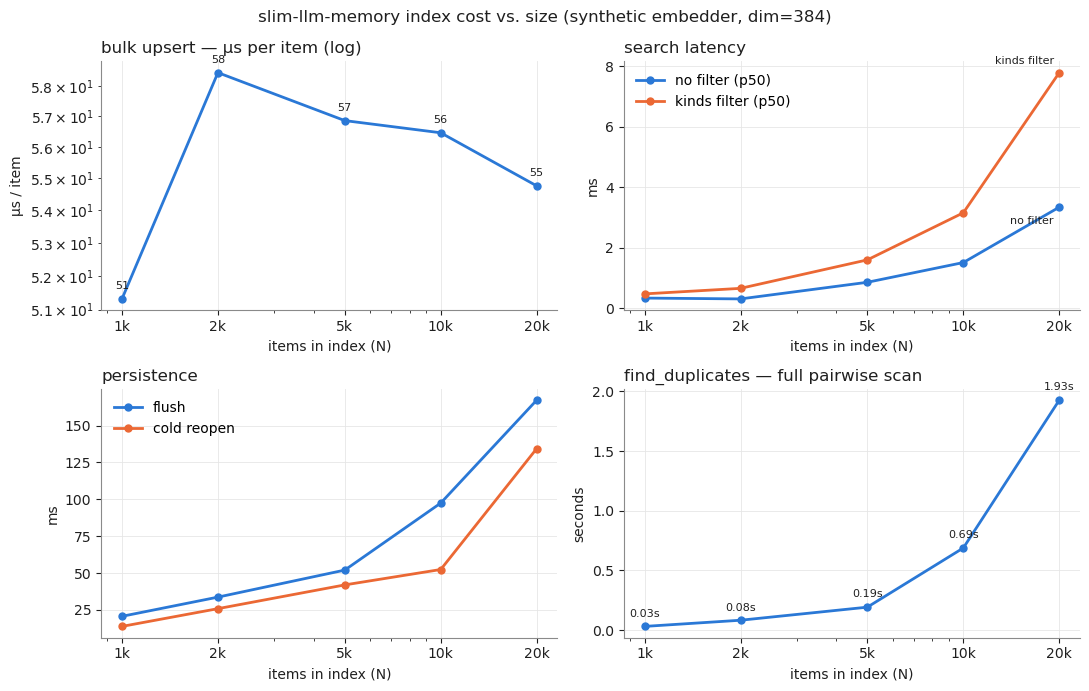

In [16]:
import matplotlib
import matplotlib.pyplot as plt
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#1f1f1f", "#8a8a8a"
plt.rcParams.update({"font.size": 10, "axes.edgecolor": MUTED, "axes.labelcolor": INK,
                     "xtick.color": INK, "ytick.color": INK, "axes.spines.top": False, "axes.spines.right": False})
ns = [r["n"] for r in bench]
fig, ax = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("slim-llm-memory index cost vs. size (synthetic embedder, dim=384)", color=INK)

def style(a, title, ylabel):
    a.set_title(title, loc="left", color=INK); a.set_xlabel("items in index (N)"); a.set_ylabel(ylabel)
    a.grid(True, color="#e6e6e6", linewidth=0.6); a.set_axisbelow(True); a.set_xscale("log")
    a.set_xticks(ns); a.set_xticklabels([f"{n//1000}k" for n in ns])

a = ax[0][0]; y = [r["upsert_us_per_item"] for r in bench]
a.plot(ns, y, color=BLUE, linewidth=2, marker="o", markersize=5); a.set_yscale("log")
for n_, v in zip(ns, y): a.annotate(f"{v:.0f}", (n_, v), textcoords="offset points", xytext=(0, 7), ha="center", color=INK, fontsize=8)
style(a, "bulk upsert — µs per item (log)", "µs / item")

a = ax[0][1]
a.plot(ns, [r["search_p50_ms"] for r in bench], color=BLUE, linewidth=2, marker="o", markersize=5, label="no filter (p50)")
a.plot(ns, [r["search_filter_p50_ms"] for r in bench], color=ORANGE, linewidth=2, marker="o", markersize=5, label="kinds filter (p50)")
a.annotate("no filter", (ns[-1], bench[-1]["search_p50_ms"]), textcoords="offset points", xytext=(-4, -12), ha="right", color=INK, fontsize=8)
a.annotate("kinds filter", (ns[-1], bench[-1]["search_filter_p50_ms"]), textcoords="offset points", xytext=(-4, 6), ha="right", color=INK, fontsize=8)
a.legend(frameon=False, loc="upper left"); style(a, "search latency", "ms")

a = ax[1][0]
a.plot(ns, [r["flush_s"] * 1000 for r in bench], color=BLUE, linewidth=2, marker="o", markersize=5, label="flush")
a.plot(ns, [r["reopen_s"] * 1000 for r in bench], color=ORANGE, linewidth=2, marker="o", markersize=5, label="cold reopen")
a.legend(frameon=False, loc="upper left"); style(a, "persistence", "ms")

a = ax[1][1]; y = [r["dups_s"] for r in bench]
a.plot(ns, y, color=BLUE, linewidth=2, marker="o", markersize=5)
for n_, v in zip(ns, y): a.annotate(f"{v:.2f}s", (n_, v), textcoords="offset points", xytext=(0, 7), ha="center", color=INK, fontsize=8)
style(a, "find_duplicates — full pairwise scan", "seconds")
plt.tight_layout(); plt.show()

### Reading the speed numbers

* **Search** is a single numpy dot product over an `(N, 384)` float32 array plus a Python loop that builds the tombstone / kind mask. It stays in the low-millisecond range through 20 k items; the `kinds` filter roughly doubles the cost because the mask loop touches every item's `meta` dict in Python.
* **Flush / reopen** are dominated by the `.npy` write/read and are effectively I/O bound — tens to a few hundred ms at 20 k.
* **`find_duplicates`** is O(N²) by design (documented as "fine up to ~50 k"); the chunked matmul keeps memory bounded.
* **Bulk upsert** is where to look: `Store.add_item` does `np.vstack` per item, which copies the whole vector array on every insert → O(N²) bytes copied. The per-item µs figure climbs with N instead of staying flat. The hash-skip path (re-upserting unchanged items) is unaffected because it never touches the vector array. If this matters for your workload, batch-append vectors once per `upsert()` call instead of per item.

## Part 3 — Use cases with a real embedder (Ollama · `nomic-embed-text`, 768-d)

Everything below runs against your local Ollama. If it isn't reachable or the model isn't pulled, the cells
print *skipped* and the notebook still completes. Corpora are kept small (< 100 texts) because CPU embedding
is ~100–200 ms per text.

In [17]:
import httpx
OLLAMA_URL = os.environ.get("OLLAMA_URL", "http://localhost:11434")
EMBED_MODEL = os.environ.get("EMBED_MODEL", "nomic-embed-text")
OLLAMA_OK = False
try:
    tags = httpx.get(f"{OLLAMA_URL}/api/tags", timeout=3).json()
    names = {m["name"].split(":")[0] for m in tags.get("models", [])}
    OLLAMA_OK = EMBED_MODEL.split(":")[0] in names
    print("ollama reachable; models:", sorted(names))
    if not OLLAMA_OK: print(f"→ run: ollama pull {EMBED_MODEL}")
except Exception as e:
    print("ollama not reachable:", e)

def skip(): print("⏭  skipped — Ollama / embedding model not available")

if OLLAMA_OK:
    part("13. real embedder")
    real = CountingEmbedder(Embedder.ollama(EMBED_MODEL, base_url=OLLAMA_URL))
    with Timer() as t: v = real.embed(["warm-up"])
    print(f"first embed (model load): {t.ms:.0f} ms, dim={len(v[0])}")
    check("nomic-embed-text returns 768-d vectors", len(v[0]) == 768)
    real.dim = real.inner.dim

ollama reachable; models: ['deepseek-v4-pro', 'glm-5.2', 'glm-5.3', 'gpt-oss', 'kimi-k2.6', 'kimi-k3', 'llama3.2', 'nomic-embed-text', 'qwen2.5']


first embed (model load): 3622 ms, dim=768
✅ nomic-embed-text returns 768-d vectors 


In [18]:
# Use case 1 — personal "second brain": mixed-language notes, ask in natural language
if not OLLAMA_OK: skip()
else:
    part("14. UC personal notes")
    NOTES = [
        ("nginx-setup",  "note",      "How to set up nginx on Ubuntu: apt install nginx, create a server block in /etc/nginx/sites-available, enable TLS with certbot."),
        ("nginx-tune",   "note",      "nginx performance tuning: worker_processes auto, keepalive_timeout 65, enable gzip for text/css and application/json."),
        ("pg-vacuum",    "knowledge", "PostgreSQL: VACUUM ANALYZE refreshes planner statistics. Run it after large bulk inserts or the query plans go bad."),
        ("pg-index",     "knowledge", "Postgres partial indexes: CREATE INDEX ... WHERE deleted = false keeps the index small for soft-delete tables."),
        ("shop-1",       "shopping",  "Milch, Brot und Butter kaufen."),
        ("shop-2",       "shopping",  "Buy a USB-C to HDMI cable for the laptop and a new mouse."),
        ("shop-3",       "shopping",  "Wochenendeinkauf: Kaffee, Äpfel, Haferflocken, Spülmittel."),
        ("idea-digest",  "idea",      "Idea: weekly digest of saved bookmarks, summarised by a small local LLM every Sunday morning."),
        ("idea-garden",  "idea",      "Idee: Balkon-Hochbeet mit Tomaten und Basilikum im Frühling anlegen."),
        ("contact-tax",  "reference", "Steuerberater Mayer, Telefon +43 1 234 5678, office@mayer-tax.example — Termin immer im Februar."),
        ("contact-dent", "reference", "Zahnarzt Dr. Huber, Praxis in der Hauptstraße 12, Tel 0660 123456."),
        ("travel-jp",    "note",      "Japan trip planning: fly into Tokyo Haneda, JR pass for 7 days, Kyoto for temples, Osaka for street food."),
        ("recipe-curry", "note",      "Thai green curry: coconut milk, green curry paste, chicken thigh, thai basil, fish sauce, palm sugar."),
        ("py-asyncio",   "knowledge", "Python asyncio: use asyncio.to_thread for blocking I/O inside async code; never block the event loop."),
        ("git-rebase",   "knowledge", "git rebase -i HEAD~5 to squash commits; use --autosquash with fixup! commits."),
    ]
    brain = Memory(fresh_dir("brain"), real)
    with Timer() as t: r = brain.upsert([{"id": i, "text": txt, "meta": {"kind": k}} for i, k, txt in NOTES])
    print(f"indexed {len(NOTES)} notes in {t.s:.2f}s ({t.s/len(NOTES)*1000:.0f} ms/note, {r['embed_calls']} HTTP call)\n")

    QUERIES = [  # (query, expected id(s) in top-2, optional kinds filter)
        ("how do I install a web server with https?",   "nginx-setup",  None),
        ("what do I need to buy at the supermarket?",    {"shop-1", "shop-2", "shop-3"}, None),  # any shopping note
        ("phone number of my tax accountant",            "contact-tax",  None),
        ("database query plans are slow after import",   "pg-vacuum",    None),
        ("Einkaufsliste Lebensmittel",                    "shop-3",       {"shopping"}),  # DE query
        ("dentist appointment",                          "contact-dent", {"reference"}),
        ("squash my last commits",                       "git-rebase",   None),
        ("trip to Asia",                                 "travel-jp",    None),
    ]
    for q, want, kinds in QUERIES:
        with Timer() as t: hits = brain.search(q, k=3, kinds=kinds)
        top = [h.id for h in hits[:2]]; wants = want if isinstance(want, set) else {want}
        print(f"? {q!r}" + (f"  kinds={kinds}" if kinds else "") + f"   [{t.ms:.0f} ms]")
        for h in hits: print(f"     {h.score:.3f}  {h.id:<13} {h.text[:70]}")
        check(f"UC-notes: {q[:40]!r} → {sorted(wants)} in top-2", bool(wants & set(top)), top)
    brain.flush()

indexed 15 notes in 12.16s (811 ms/note, 1 HTTP call)

? 'how do I install a web server with https?'   [55 ms]
     0.557  nginx-setup   How to set up nginx on Ubuntu: apt install nginx, create a server bloc
     0.447  git-rebase    git rebase -i HEAD~5 to squash commits; use --autosquash with fixup! c
     0.397  py-asyncio    Python asyncio: use asyncio.to_thread for blocking I/O inside async co
✅ UC-notes: 'how do I install a web server with https' → ['nginx-setup'] in top-2 — ['nginx-setup', 'git-rebase']
? 'what do I need to buy at the supermarket?'   [93 ms]
     0.469  recipe-curry  Thai green curry: coconut milk, green curry paste, chicken thigh, thai
     0.446  shop-2        Buy a USB-C to HDMI cable for the laptop and a new mouse.
     0.429  travel-jp     Japan trip planning: fly into Tokyo Haneda, JR pass for 7 days, Kyoto 
✅ UC-notes: 'what do I need to buy at the supermarket' → ['shop-1', 'shop-2', 'shop-3'] in top-2 — ['recipe-curry', 'shop-2']
? 'phone number of my ta

? 'database query plans are slow after import'   [434 ms]
     0.627  pg-vacuum     PostgreSQL: VACUUM ANALYZE refreshes planner statistics. Run it after 
     0.470  pg-index      Postgres partial indexes: CREATE INDEX ... WHERE deleted = false keeps
     0.438  nginx-tune    nginx performance tuning: worker_processes auto, keepalive_timeout 65,
✅ UC-notes: 'database query plans are slow after impo' → ['pg-vacuum'] in top-2 — ['pg-vacuum', 'pg-index']


? 'Einkaufsliste Lebensmittel'  kinds={'shopping'}   [581 ms]
     0.636  shop-1        Milch, Brot und Butter kaufen.
     0.633  shop-3        Wochenendeinkauf: Kaffee, Äpfel, Haferflocken, Spülmittel.
     0.337  shop-2        Buy a USB-C to HDMI cable for the laptop and a new mouse.
✅ UC-notes: 'Einkaufsliste Lebensmittel' → ['shop-3'] in top-2 — ['shop-1', 'shop-3']
? 'dentist appointment'  kinds={'reference'}   [99 ms]
     0.412  contact-tax   Steuerberater Mayer, Telefon +43 1 234 5678, office@mayer-tax.example 
     0.370  contact-dent  Zahnarzt Dr. Huber, Praxis in der Hauptstraße 12, Tel 0660 123456.
✅ UC-notes: 'dentist appointment' → ['contact-dent'] in top-2 — ['contact-tax', 'contact-dent']


? 'squash my last commits'   [1067 ms]
     0.664  git-rebase    git rebase -i HEAD~5 to squash commits; use --autosquash with fixup! c
     0.453  pg-index      Postgres partial indexes: CREATE INDEX ... WHERE deleted = false keeps
     0.421  shop-1        Milch, Brot und Butter kaufen.
✅ UC-notes: 'squash my last commits' → ['git-rebase'] in top-2 — ['git-rebase', 'pg-index']
? 'trip to Asia'   [140 ms]
     0.680  travel-jp     Japan trip planning: fly into Tokyo Haneda, JR pass for 7 days, Kyoto 
     0.503  recipe-curry  Thai green curry: coconut milk, green curry paste, chicken thigh, thai
     0.471  idea-garden   Idee: Balkon-Hochbeet mit Tomaten und Basilikum im Frühling anlegen.
✅ UC-notes: 'trip to Asia' → ['travel-jp'] in top-2 — ['travel-jp', 'recipe-curry']


In [19]:
# Use case 2 — RAG over this repository's own docs
def chunk_markdown(path: Path, max_chars=500):
    '''Split by blank lines, merge small paragraphs, remember the nearest heading.'''
    heading, buf, chunks = "", "", []
    for para in path.read_text(encoding="utf-8").split("\n\n"):
        para = para.strip()
        if not para: continue
        if para.startswith("#"):
            if buf: chunks.append((heading, buf)); buf = ""
            first, _, rest = para.partition("\n")          # heading may be glued to its body (no blank line)
            heading = first.lstrip("# ").strip(); para = rest.strip()
            if not para: continue
        if len(buf) + len(para) > max_chars and buf:
            chunks.append((heading, buf)); buf = ""
        buf = (buf + "\n\n" + para).strip()
    if buf: chunks.append((heading, buf))
    return [{"id": f"{path.name}#{i}", "text": f"{h}\n{b}" if h else b, "meta": {"kind": "doc", "file": path.name, "heading": h}}
            for i, (h, b) in enumerate(chunks)]

if not OLLAMA_OK: skip()
else:
    part("15. UC RAG over docs")
    DOC_CHUNKS = chunk_markdown(REPO / "README.md") + chunk_markdown(REPO / "docs" / "IMPLEMENTATION.md")
    print(f"{len(DOC_CHUNKS)} chunks, {sum(len(c['text']) for c in DOC_CHUNKS)/1000:.1f} k chars")
    RAG_DIR = fresh_dir("rag")
    rag = Memory(RAG_DIR, real)
    with Timer() as t: r = rag.upsert(DOC_CHUNKS)
    RAG_INDEX_S = t.s
    print(f"indexed in {t.s:.1f}s ({t.s/len(DOC_CHUNKS)*1000:.0f} ms/chunk)\n")

    RAG_Q = [
        ("How is a flush made atomic / crash safe?",                   ["manifest", "atomic"]),
        ("When does compaction of tombstones happen?",                 ["tombstone", "compaction"]),
        ("Which embedders are supported and which is for tests?",      ["noop"]),
        ("How do I avoid re-embedding unchanged items?",               ["changed"]),
        ("what are the hard dependencies of the library",              ["numpy", "httpx"]),
    ]
    for q, keywords in RAG_Q:
        with Timer() as t: hits = rag.search(q, k=3, kinds={"doc"})
        ctx = " ".join(h.text.lower() for h in hits)
        print(f"? {q}   [{t.ms:.0f} ms]")
        for h in hits: print(f"     {h.score:.3f}  {h.meta['file']:<18} § {h.meta['heading'][:38]:<38}")
        check(f"UC-rag: {q[:45]!r} → top-3 context mentions {keywords}", all(kw.lower() in ctx for kw in keywords))
    rag.flush()
    # A prompt you'd hand to an LLM:
    hits = rag.search(RAG_Q[0][0], k=2, kinds={"doc"})
    prompt = "Answer using only the context.\n\n" + "\n---\n".join(h.text for h in hits) + f"\n\nQ: {RAG_Q[0][0]}\nA:"
    print("\n─ example LLM prompt (truncated) ─\n" + textwrap.shorten(prompt, 600))

79 chunks, 24.2 k chars


indexed in 35.3s (447 ms/chunk)

? How is a flush made atomic / crash safe?   [169 ms]
     0.790  IMPLEMENTATION.md  § 8. flush to disk (atomic — safe to cra
     0.693  README.md          § Atomic persistence — safe to crash mid
     0.586  README.md          § Persistence model                     
✅ UC-rag: 'How is a flush made atomic / crash safe?' → top-3 context mentions ['manifest', 'atomic'] 


? When does compaction of tombstones happen?   [56 ms]
     0.570  IMPLEMENTATION.md  § Invariants                            
     0.532  README.md          § Persistence model                     
     0.514  README.md          § What's in the box (phase 1)           
✅ UC-rag: 'When does compaction of tombstones happen?' → top-3 context mentions ['tombstone', 'compaction'] 
? Which embedders are supported and which is for tests?   [106 ms]
     0.677  IMPLEMENTATION.md  § Phase 2 — `Embedder.gemini` cloud fall
     0.660  IMPLEMENTATION.md  § Tests (per phase, see §6)             
     0.648  README.md          § Atomic persistence — safe to crash mid
✅ UC-rag: 'Which embedders are supported and which is fo' → top-3 context mentions ['noop'] 


? How do I avoid re-embedding unchanged items?   [158 ms]
     0.657  IMPLEMENTATION.md  § 2. add / update items (incremental — o
     0.643  README.md          § Add or update items — only changed tex
     0.643  IMPLEMENTATION.md  § 5. update one item's text (triggers re
✅ UC-rag: 'How do I avoid re-embedding unchanged items?' → top-3 context mentions ['changed'] 


? what are the hard dependencies of the library   [309 ms]
     0.594  IMPLEMENTATION.md  § 12. Reference dependency footprint    
     0.576  IMPLEMENTATION.md  § 12. Reference dependency footprint    
     0.548  IMPLEMENTATION.md  § 14. First commit checklist (for a fres
✅ UC-rag: 'what are the hard dependencies of the library' → top-3 context mentions ['numpy', 'httpx'] 

─ example LLM prompt (truncated) ─
Answer using only the context. 8. flush to disk (atomic — safe to crash mid-anything) mem.flush() --- Atomic persistence — safe to crash mid-anything mem.flush() ``` `Embedder.noop()` exists for tests and offline development — same interface, deterministic SHA-256 derived vectors, no network. Q: How is a flush made atomic / crash safe? A:


In [20]:
# Use case 3 — incremental re-index after editing one paragraph (the hash-skip payoff with a real embedder)
if not OLLAMA_OK: skip()
else:
    part("16. UC incremental re-index")
    edited = [dict(c) for c in DOC_CHUNKS]
    edited[3]["text"] = edited[3]["text"] + "\n\n(edited: this paragraph changed.)"
    texts_before = real.texts
    with Timer() as t: r = rag.upsert(edited)
    print(f"re-upsert of {len(edited)} chunks with 1 edit: {r}  in {t.s*1000:.0f} ms  (full index took {RAG_INDEX_S:.1f}s)")
    check("only the edited chunk hit the embedder", real.texts - texts_before == 1 and r["updated"] == 1 and r["skipped"] == len(edited) - 1, r)
    check("incremental re-index ≥ 10× faster than full index", t.s * 10 < RAG_INDEX_S, f"{RAG_INDEX_S / t.s:.0f}×")

    # Reopen from disk in a new process-equivalent and confirm zero embeds for an unchanged corpus.
    rag.close()
    real2 = CountingEmbedder(Embedder.ollama(EMBED_MODEL, base_url=OLLAMA_URL)); real2.dim = 768
    with Timer() as t: rag2 = Memory(RAG_DIR, real2)
    print(f"cold reopen: {t.ms:.0f} ms, {rag2.stats()['items_open']} chunks")
    r = rag2.upsert(edited)
    check("after reopen, unchanged corpus → 0 embed calls", real2.texts == 0 and r["skipped"] == len(edited), r)
    rag2.close()

re-upsert of 79 chunks with 1 edit: {'added': 0, 'updated': 1, 'skipped': 78, 'embed_calls': 1}  in 67 ms  (full index took 35.3s)
✅ only the edited chunk hit the embedder — {'added': 0, 'updated': 1, 'skipped': 78, 'embed_calls': 1}
✅ incremental re-index ≥ 10× faster than full index — 524×
cold reopen: 1 ms, 79 chunks
✅ after reopen, unchanged corpus → 0 embed calls — {'added': 0, 'updated': 0, 'skipped': 79, 'embed_calls': 0}


In [21]:
# Use case 4 — near-duplicate detection across paraphrases
if not OLLAMA_OK: skip()
else:
    part("17. UC near-duplicates")
    PARA = [
        ("n1", "Remember to renew the car insurance before the end of March."),
        ("n2", "Car insurance renewal is due by end of March — don't forget."),
        ("n3", "TODO: renew auto insurance policy, deadline March 31."),
        ("m1", "Meeting with Anna about the Q3 roadmap on Tuesday at 10."),
        ("m2", "Tuesday 10:00 — roadmap sync with Anna (Q3 planning)."),
        ("x1", "Recipe: sourdough starter needs feeding twice a day at room temperature."),
        ("x2", "The dishwasher is leaking again; call the repair service."),
    ]
    dd = Memory(fresh_dir("dedup"), real)
    dd.upsert([{"id": i, "text": t} for i, t in PARA])
    for th in (0.90, 0.80, 0.70):
        with Timer() as t: cl = dd.find_duplicates(threshold=th)
        print(f"θ={th:.2f}  [{t.ms:.1f} ms]  clusters: {sorted(sorted(c) for c in cl)}")
    cl = sorted(sorted(c) for c in dd.find_duplicates(threshold=0.80))
    ins = next((c for c in cl if "n1" in c), []); mtg = next((c for c in cl if "m1" in c), [])
    check("insurance paraphrases cluster together at θ=0.80", set(ins) >= {"n1", "n2", "n3"}, ins)
    check("meeting paraphrases cluster together at θ=0.80", set(mtg) >= {"m1", "m2"}, mtg)
    check("unrelated notes are not clustered", not any("x1" in c or "x2" in c for c in cl), cl)
    check("insurance and meeting are separate clusters", not (set(ins) & set(mtg)))
    # Pairwise scores for the curious:
    V = dd.store.vectors; ids = [it.id for it in dd.store.items]
    S = V @ V.T
    print("\ncosine matrix:"); print("      " + " ".join(f"{i:>5}" for i in ids))
    for i, row in zip(ids, S): print(f"{i:>5} " + " ".join(f"{v:5.2f}" for v in row))
    dd.close()

θ=0.90  [0.1 ms]  clusters: [['m1', 'm2'], ['n1', 'n2']]
θ=0.80  [0.1 ms]  clusters: [['m1', 'm2'], ['n1', 'n2', 'n3']]
θ=0.70  [0.1 ms]  clusters: [['m1', 'm2'], ['n1', 'n2', 'n3']]
✅ insurance paraphrases cluster together at θ=0.80 — ['n1', 'n2', 'n3']
✅ meeting paraphrases cluster together at θ=0.80 — ['m1', 'm2']
✅ unrelated notes are not clustered — [['m1', 'm2'], ['n1', 'n2', 'n3']]
✅ insurance and meeting are separate clusters 

cosine matrix:
         n1    n2    n3    m1    m2    x1    x2
   n1  1.00  0.93  0.82  0.44  0.44  0.40  0.40
   n2  0.93  1.00  0.84  0.46  0.46  0.41  0.45
   n3  0.82  0.84  1.00  0.49  0.51  0.44  0.47
   m1  0.44  0.46  0.49  1.00  0.90  0.43  0.41
   m2  0.44  0.46  0.51  0.90  1.00  0.44  0.41
   x1  0.40  0.41  0.44  0.43  0.44  1.00  0.52
   x2  0.40  0.45  0.47  0.41  0.41  0.52  1.00


In [22]:
# Use case 5 — conversation memory: retrieve relevant past turns for a new user message
if not OLLAMA_OK: skip()
else:
    part("18. UC chat memory")
    TURNS = [
        ("t01", "user",      "I'm training for a half marathon in October, my long run is 14 km right now."),
        ("t02", "assistant", "Nice — for a half in October, build the long run by ~1 km a week and add one tempo session."),
        ("t03", "user",      "My knee hurts a bit after the long runs, on the outside."),
        ("t04", "assistant", "Outside-knee pain after long runs is often IT band irritation; try foam rolling and reduce weekly volume 20%."),
        ("t05", "user",      "Unrelated: can you remind me how to set up a Python virtualenv?"),
        ("t06", "assistant", "python -m venv .venv && source .venv/bin/activate, then pip install -r requirements.txt."),
        ("t07", "user",      "I'm vegetarian, so recipe suggestions should skip meat."),
        ("t08", "assistant", "Noted — vegetarian only. Lentil dal, chickpea curry, and halloumi wraps are good high-protein options."),
        ("t09", "user",      "What's a good playlist for running?"),
        ("t10", "assistant", "Try 170–180 BPM tracks to match cadence; drum & bass or fast pop works well."),
    ]
    chat = Memory(fresh_dir("chat"), real)
    chat.upsert([{"id": i, "text": f"{role}: {txt}", "meta": {"kind": role, "turn": n}} for n, (i, role, txt) in enumerate(TURNS)])

    def recall(msg, k=3, kinds=None):
        with Timer() as t: hits = chat.search(msg, k=k, kinds=kinds, min_score=0.4)
        print(f"\nnew message: {msg!r}   [{t.ms:.0f} ms]")
        for h in hits: print(f"   {h.score:.3f}  #{h.meta['turn']:02d} {h.text[:80]}")
        return [h.id for h in hits]

    got = recall("the pain on the side of my knee is back after yesterday's 16 km")
    check("UC-chat: knee message recalls the IT-band exchange", "t03" in got or "t04" in got, got)
    got = recall("suggest something for dinner tonight")
    check("UC-chat: dinner recalls the vegetarian constraint", "t07" in got or "t08" in got, got)
    got = recall("how many weeks until my race and what should my long run be?", kinds={"user"})
    check("UC-chat: kinds={'user'} returns only user turns", all(i in {"t01", "t03", "t05", "t07", "t09"} for i in got) and "t01" in got, got)
    got = recall("how do I activate the venv again?")
    check("UC-chat: venv question recalls the venv answer", "t06" in got, got)
    chat.close()


new message: "the pain on the side of my knee is back after yesterday's 16 km"   [55 ms]
   0.769  #02 user: My knee hurts a bit after the long runs, on the outside.
   0.739  #03 assistant: Outside-knee pain after long runs is often IT band irritation; try fo
   0.597  #00 user: I'm training for a half marathon in October, my long run is 14 km right no
✅ UC-chat: knee message recalls the IT-band exchange — ['t03', 't04', 't01']

new message: 'suggest something for dinner tonight'   [91 ms]
   0.503  #06 user: I'm vegetarian, so recipe suggestions should skip meat.
   0.478  #07 assistant: Noted — vegetarian only. Lentil dal, chickpea curry, and halloumi wra
   0.451  #08 user: What's a good playlist for running?
✅ UC-chat: dinner recalls the vegetarian constraint — ['t07', 't08', 't09']

new message: 'how many weeks until my race and what should my long run be?'   [55 ms]
   0.727  #00 user: I'm training for a half marathon in October, my long run is 14 km right no
   0.591  #02 user

In [23]:
# Use case 6 — end-to-end latency with a real embedder: where does the time go?
if not OLLAMA_OK: skip()
else:
    part("19. real-embedder latency")
    print("embed batch throughput (Ollama CPU/GPU dependent):")
    for bs in (1, 8, 32):
        texts = [f"benchmark sentence number {i} about embeddings and retrieval" for i in range(bs)]
        with Timer() as t: real.embed(texts)
        print(f"   batch={bs:>2}: {t.ms:7.0f} ms total, {t.ms/bs:6.0f} ms/text")

    # search = 1 query embed + numpy scan. Separate the two by memoising the embedder:
    # the first search pays for the embed, the second hits the cache and measures the index alone.
    class MemoEmbedder(Embedder):
        def __init__(self, inner): self.inner, self.name, self.dim, self.cache = inner, inner.name, inner.dim, {}
        def embed(self, texts):
            miss = [t for t in texts if t not in self.cache]
            if miss: self.cache.update(zip(miss, self.inner.embed(miss)))
            return [self.cache[t] for t in texts]
    brain.embedder = MemoEmbedder(real)
    lat_total, lat_scan = [], []
    for i in range(10):
        q = f"question {i} about nginx configuration"
        with Timer() as t1: brain.search(q, k=3)      # embed + scan
        with Timer() as t2: brain.search(q, k=3)      # cached embed → scan only
        lat_total.append(t1.ms); lat_scan.append(t2.ms)
    print(f"\nsearch on {brain.stats()['items_open']} notes: p50 end-to-end {statistics.median(lat_total):.0f} ms, "
          f"index scan alone {statistics.median(lat_scan):.2f} ms → embedding is {100 * (1 - statistics.median(lat_scan) / statistics.median(lat_total)):.1f}% of the latency")
    check("real-embedder search: index scan < 5% of end-to-end latency", statistics.median(lat_scan) < 0.05 * statistics.median(lat_total))
    print("\nobs counters for the notes brain:", brain.stats()["counters"])
    print("slow queries (>100 ms) recorded:", len(brain.stats()["slow_queries"]))
    brain.close()

embed batch throughput (Ollama CPU/GPU dependent):
   batch= 1:      50 ms total,     50 ms/text


   batch= 8:     256 ms total,     32 ms/text


   batch=32:    4859 ms total,    152 ms/text



search on 15 notes: p50 end-to-end 808 ms, index scan alone 0.10 ms → embedding is 100.0% of the latency
✅ real-embedder search: index scan < 5% of end-to-end latency 

obs counters for the notes brain: {'embed.calls': 1, 'embed.items': 15, 'upsert.added': 15, 'search.calls': 28}
slow queries (>100 ms) recorded: 10


## Summary

In [24]:
from collections import OrderedDict
groups = OrderedDict()
for p, n, ok, dt in RESULTS:
    groups.setdefault(p, []).append((n, ok, dt))
w = max(len(p) for p in groups)
print(f"{'section':<{w}}  pass/total")
print("─" * (w + 12))
for p, rows in groups.items():
    ok = sum(1 for _, o, _ in rows if o)
    unexpected = [n for n, o, _ in rows if not o and n not in KNOWN]
    print(f"{p:<{w}}  {ok:>3}/{len(rows):<3} {'✅' if ok == len(rows) else ('⚠️' if not unexpected else '❌')}")
print("─" * (w + 12))
total_ok = sum(1 for r in RESULTS if r[2])
print(f"{'TOTAL':<{w}}  {total_ok:>3}/{len(RESULTS)}")
print("Part 3 (Ollama):", "ran" if OLLAMA_OK else "skipped — no Ollama / model")
failed = [(p, n, dt) for p, n, ok, dt in RESULTS if not ok and n not in KNOWN]
known = [(p, n, dt) for p, n, ok, dt in RESULTS if not ok and n in KNOWN]
print("\nUnexpected failures:" if failed else "\nNo unexpected failures.")
for p, n, dt in failed: print(f"  ❌ [{p}] {n} — {dt}")
if known:
    print("\nKnown library issues documented by this notebook (fix → they turn ✅):")
    for p, n, dt in known: print(f"  ⚠️  [{p}] {n} — {dt}")

section                                         pass/total
──────────────────────────────────────────────────────────
1. upsert semantics                               5/5   ✅
2. hash-skip incremental re-index                 8/8   ✅
3. search basics, filters, edge cases            13/13  ✅
4. remove / tombstones                            8/8   ✅
5. persistence round-trip                         9/9   ✅
6. crash safety (manifest is the commit point)    4/4   ✅
7. single-writer lock & embedder fingerprint      7/7   ✅
8. compaction (>20% tombstones)                   7/7   ✅
9. duplicate clustering                           9/9   ✅
10. unicode, long text, validation               10/10  ✅
11. observability counters                        5/5   ✅
12. speed expectations                            7/7   ✅
13. real embedder                                 1/1   ✅
14. UC personal notes                             8/8   ✅
15. UC RAG over docs                              5/5   ✅
16. UC incre

### Bench table (Part 2)

In [25]:
cols = ["n", "upsert_s", "upsert_us_per_item", "append1k_s", "reupsert_skip_s", "search_p50_ms", "search_p95_ms",
        "search_filter_p50_ms", "flush_s", "reopen_s", "dups_s", "disk_mb"]
print(" ".join(f"{c:>20}" for c in cols))
for r in bench:
    print(" ".join(f"{r[c]:>20.3f}" if isinstance(r[c], float) else f"{r[c]:>20}" for c in cols))

                   n             upsert_s   upsert_us_per_item           append1k_s      reupsert_skip_s        search_p50_ms        search_p95_ms search_filter_p50_ms              flush_s             reopen_s               dups_s              disk_mb
                1000                0.051               51.314                0.072                0.002                0.341                6.782                0.480                0.021                0.014                0.032                3.385
                2000                0.117               58.448                0.047                0.005                0.314                1.368                0.662                0.034                0.026                0.083                5.078
                5000                0.284               56.857                0.045                0.012                0.863                6.055                1.604                0.052                0.042                0.193              